## Planning Algorithms in AI 
## PS2: Sampling-based Planning

Student: Olga Tiupina

Problem: find path for 4-joints manipulator.

## Task I: Visualization

In [1]:
import numpy as np
import pickle
from environment import State, ManipulatorEnv
import rtt_planning_lib
import matplotlib.pyplot as plt

### Tools for visualization

In [ ]:
def visualize_state(env, state, title="State"):
    env.state = state
    plt.figure(figsize=(6, 6))
    env.render(plt_show=False)
    plt.title(title)
    plt.show()


def visualize_states_single_plot(env, states, colors=None, title="All States"):
    """
    All states in the single canvas
    
    """
    plt.figure(figsize=(10, 10))
    original_state = env.state
    if colors is None:
        colors = plt.cm.rainbow(np.linspace(0, 1, len(states)))
    for i, state in enumerate(states):
        env.state = state
        joints = state.joints
        color = colors[i] if i < len(colors) else 'blue'
        for j in range(4):
            segment = joints[[j, j+1], :]
            alpha = 0.7 if i == len(states)-1 else 0.3 
            plt.plot(segment[:, 0], segment[:, 1], 'o-', 
                    color=color, alpha=alpha, linewidth=2)
    for obs in env._obstacles:
        plt.gca().add_patch(
            plt.Circle((obs[0], obs[1]), obs[2], fill=True, alpha=0.5))
    env.state = original_state
    
    plt.axis('equal')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


def make_manipulator_gif(env, state_list, gif_name="solve_4R.gif"):
    import matplotlib.animation as animation
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    def update(frame):
        ax.clear()
        env.state = state_list[frame]
        env.render(plt_show=False)
        ax.set_title(f"Step {frame+1}/{len(state_list)}")
        return []
    
    anim = animation.FuncAnimation(fig, update, frames=len(state_list), interval=300, blit=False)
    anim.save(gif_name, writer='pillow')
    plt.close()



### A

In [3]:
# load data
with open("data.pickle", "rb") as f:
    data = pickle.load(f)

start_state = State(np.array(data["start_state"]))
goal_state = State(np.array(data["goal_state"]))

env = ManipulatorEnv(
    obstacles=np.array(data["obstacles"]),
    initial_state=start_state,
    collision_threshold=data["collision_threshold"]
)

print("Start state angles:", start_state.angles)
print("Start state joints:")
print(start_state.joints)
print("Goal state angles:", goal_state.angles)
print("Goal state joints:")
print(goal_state.joints)


Start state angles: [0. 0. 0. 0.]
Start state joints:
[[0. 0.]
 [1. 0.]
 [2. 0.]
 [3. 0.]
 [4. 0.]]
Goal state angles: [-180.  -60.   72.  -60.]
Goal state joints:
[[ 0.00000000e+00  0.00000000e+00]
 [-1.00000000e+00 -1.22464680e-16]
 [-1.50000000e+00  8.66025404e-01]
 [-2.47814760e+00  6.58113713e-01]
 [-3.14727821e+00  1.40125854e+00]]


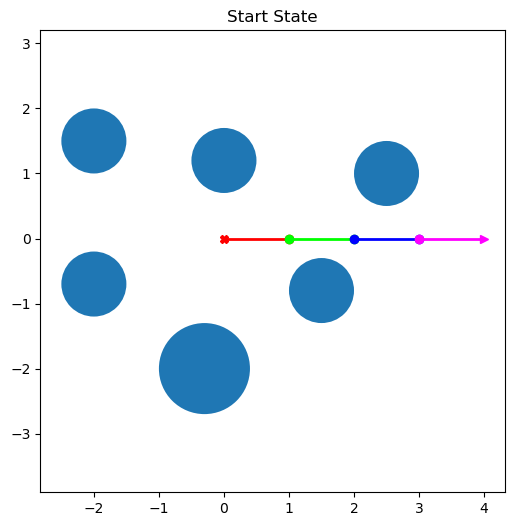

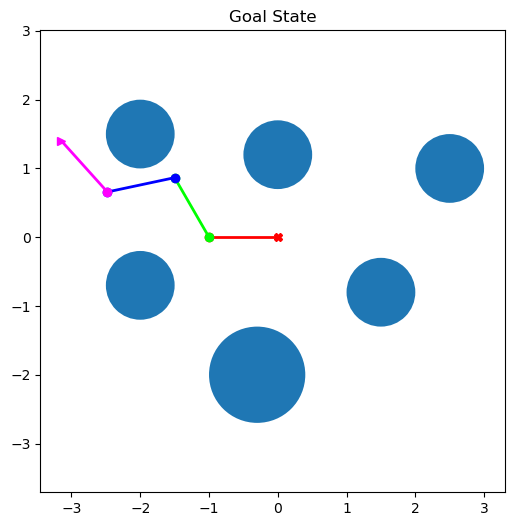

In [4]:
visualize_state(env, start_state, "Start State")
visualize_state(env, goal_state, "Goal State")


In the previous PS1 task, the orientation space was **discrete** (0, 45, 90, 135).

In this task, it is **continuous**, θ ∈ (−180°, 180°], which leads to:

- an infinite configuration space,
- smoother and more realistic robot movements,
- the need to use continuous space search methods (RRT, RRT\*\*, random sampling),
- more accurate collision checking.

This means the task becomes significantly more complex, but also closer to real robots.


### B

In [5]:
# prepare data for c++ lib
start_list = np.array(data["start_state"]).tolist()
goal_list = np.array(data["goal_state"]).tolist()
obstacles_list = np.array(data["obstacles"]).tolist()

In [6]:
planner = rtt_planning_lib.RRT(obstacles_list)
planner.set_start_goal(start_list, goal_list)

RRT has been created


In [7]:
random_states = []
collisions_list = []
for i in range(4):
    angles = planner.sample()
    state = State(np.array(angles))
    while i % 2 == 0 and planner.check_collision(angles):
        angles = planner.sample()
        state = State(np.array(angles))
    while i % 2 != 0 and not planner.check_collision(angles):
        angles = planner.sample()
        state = State(np.array(angles))
    print(planner.check_collision(angles))
    random_states.append(state)

False
True
False
True



=== Random state 1 ===
Angles: [  17.91234289 -168.48161206  -67.23489566   41.87616871]
Collision: False


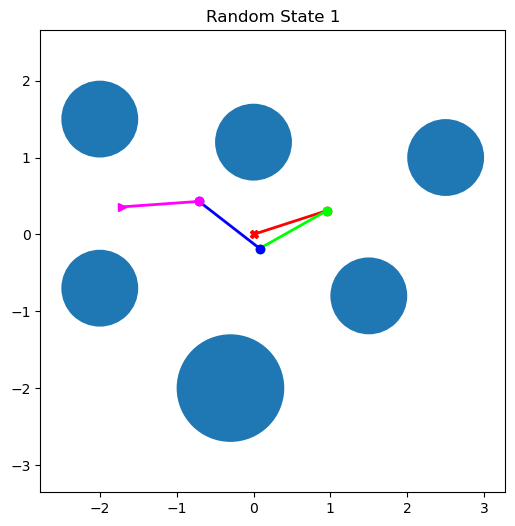


=== Random state 2 ===
Angles: [ 16.9227217  -70.99696383  -7.0800027  115.0283619 ]
Collision: True


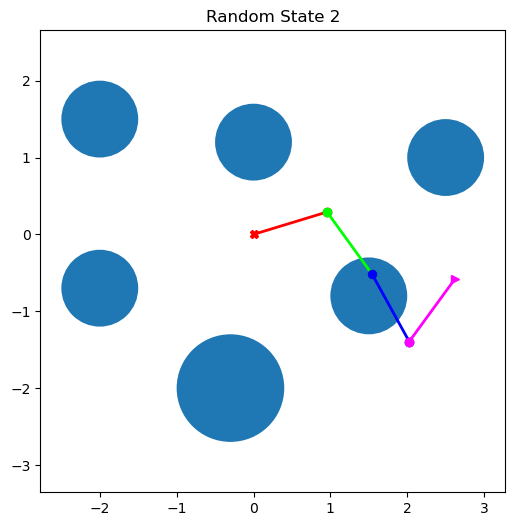


=== Random state 3 ===
Angles: [ -62.13927889 -152.8669276  -154.47889623  147.12674928]
Collision: False


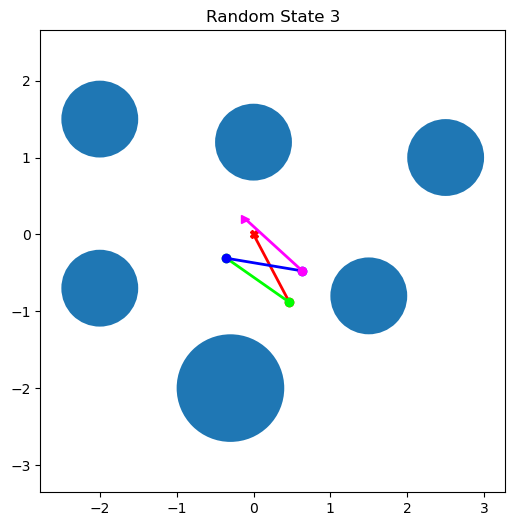


=== Random state 4 ===
Angles: [ -53.48685042 -126.48631498  157.09239744 -143.65790573]
Collision: True


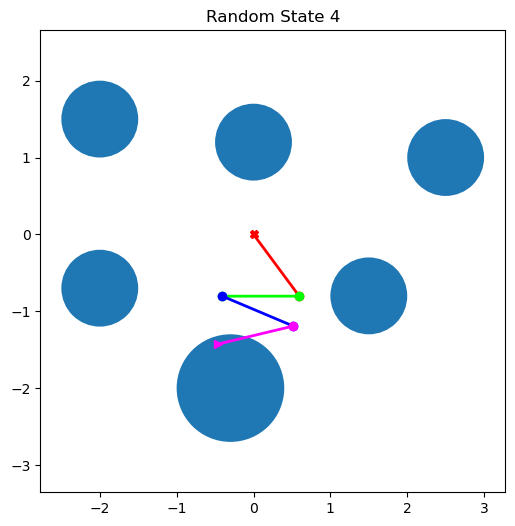

In [8]:
for i, st in enumerate(random_states, 1):
    print(f"\n=== Random state {i} ===")
    print("Angles:", st.angles)
    
    collision = env.check_collision(st)
    print("Collision:", collision)
    
    visualize_state(env, st, f"Random State {i}")


- Some random configurations lead to **collisions** when links get closer than the `collision_threshold` to an obstacle.
- The `check_collision()` function correctly detects:
- touching link ends,
- crossing the link midpoint (using projection onto a segment),
- approaching a circle.
- Intersection of links **among themselves** is allowed, as can be seen in the images.
- The manipulator geometry follows sequential SE(2) multiplication, and angle changes are clearly visible.


## Task II: Rapidly-exploring Random Trees (RRT)

### A. Implement a collision check between any two configurations

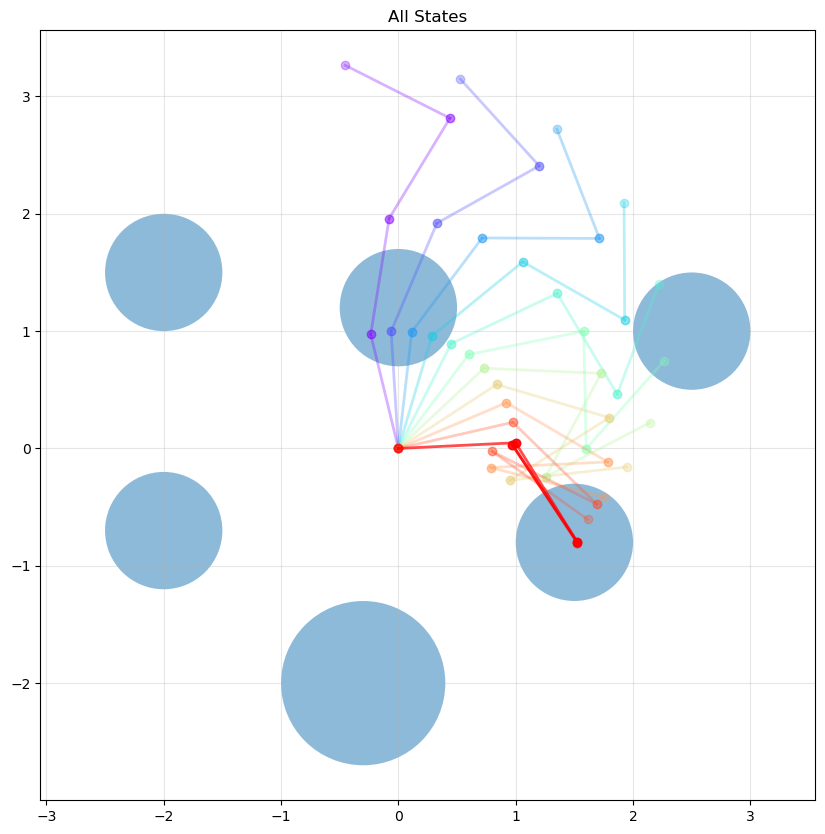

In [9]:
angles_list = planner.generate_states_btw(planner.sample(), planner.sample())
states_btw = []

for i, angles in enumerate(angles_list):
    state = State(np.array(angles))
    states_btw.append(state)
visualize_states_single_plot(env, states_btw)

### B: RRT algorithm

Find the path!
Iteration: 4867
Plan length: 50


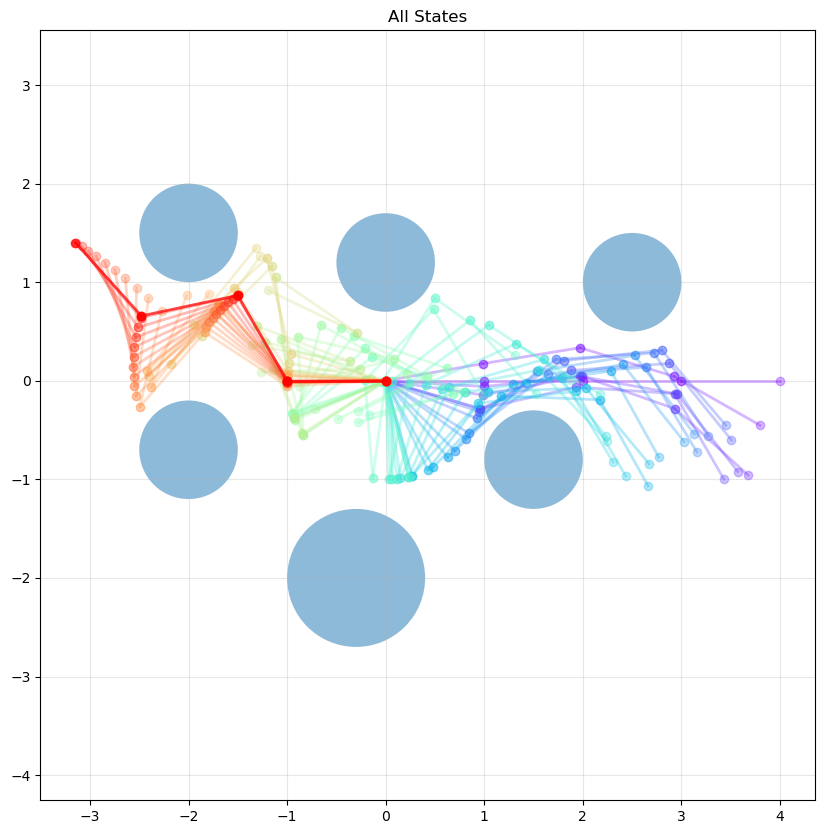

In [10]:
if planner.launch():
    plann_list = planner.get_plan()
    state_list = []
    for i, angles in enumerate(plann_list):
        state = State(np.array(angles))
        state_list.append(state)
    visualize_states_single_plot(env, state_list)
    # GIF
    make_manipulator_gif(env, state_list, "solve_4R.gif")

### C
Non-optimality planner. Also I've added probability to get final state in RRT: 5%. Iteration amount from 300 to more than 500 000. I have iteration bound equall to 500 000 to stop the algorithm.

Some outputs with probability 5%:
Iteration: 3924
Plan length: 58

Iteration: 5039
Plan length: 69

Iteration: 62323
Plan length: 64

Iteration: 8016
Plan length: 50

Some outputs without probability:

Iteration: 17562
Plan length: 63

long-long time withot results...

### D

Find the path!
Iteration: 5036
Plan length: 46


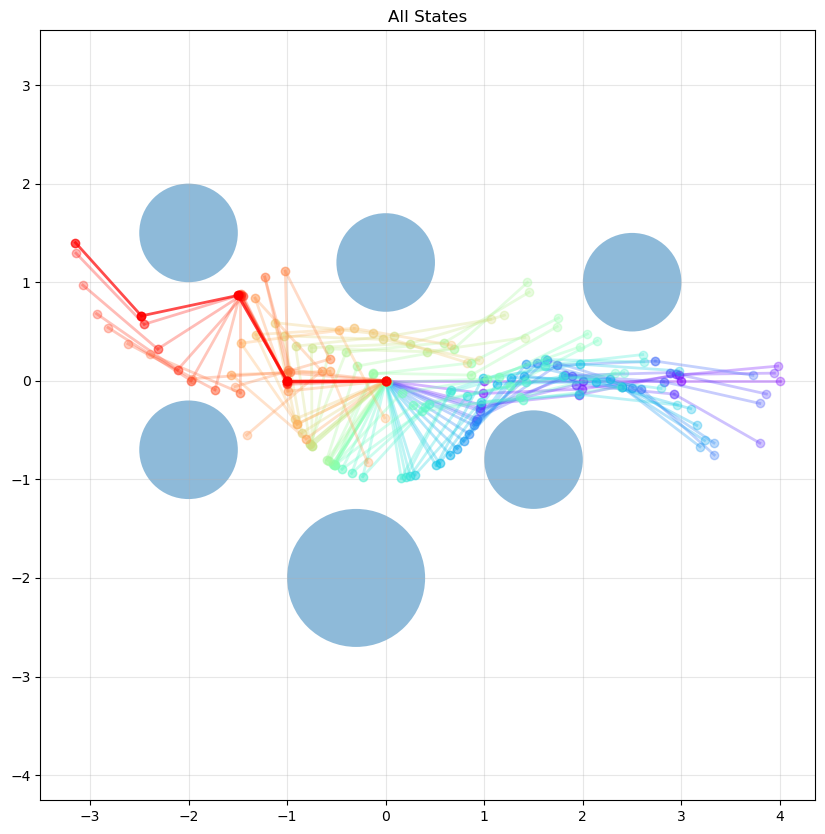

KeyboardInterrupt: 

In [ ]:
planner.set_weights_in_distant_func(0.2, 1.0, 1.0, 1.0) #easy to move nearer to base joints
if planner.launch():
    plann_list = planner.get_plan()
    state_list = []
    for i, angles in enumerate(plann_list):
        state = State(np.array(angles))
        state_list.append(state)
    visualize_states_single_plot(env, state_list)

With lower weight of nearer to base joints a little bit shorter distance is got:

weights: 0.4, 0.6, 0.8, 1.0
Iteration: 2308
Plan length: 51

weights: 0.2, 1.0, 1.0, 1.0
Iteration: 5036
Plan length: 46


### E

Find the path!
Iteration: 7603
Plan length: 119


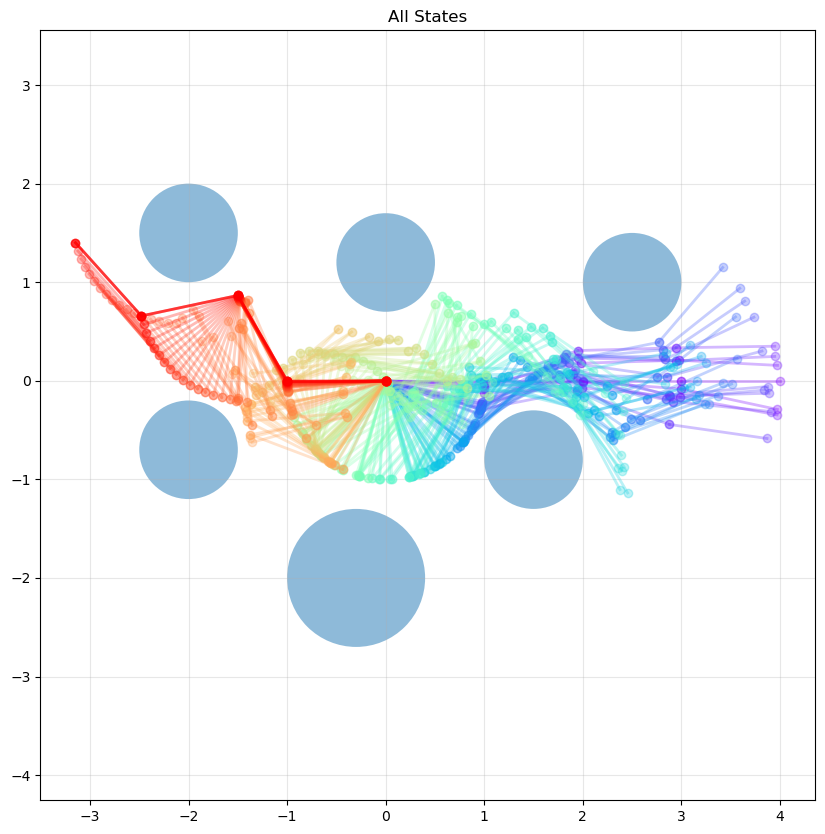

In [ ]:
planner.set_weights_in_distant_func(1.0, 1.0, 1.0, 1.0)
planner.set_step_threshold(5)
if planner.launch():
    plann_list = planner.get_plan()
    state_list = []
    for i, angles in enumerate(plann_list):
        state = State(np.array(angles))
        state_list.append(state)
    visualize_states_single_plot(env, state_list)
    # make_manipulator_gif(env, state_list, "solve_4R_5.gif")

    

With lower step like 5 degree a longer path and bigger overall iterations amout were got:

Iteration: 10858
Plan length: 114

Iteration: 7603
Plan length: 119

It connects to lower research enviroment speed.

Find the path!
Iteration: 781
Plan length: 29


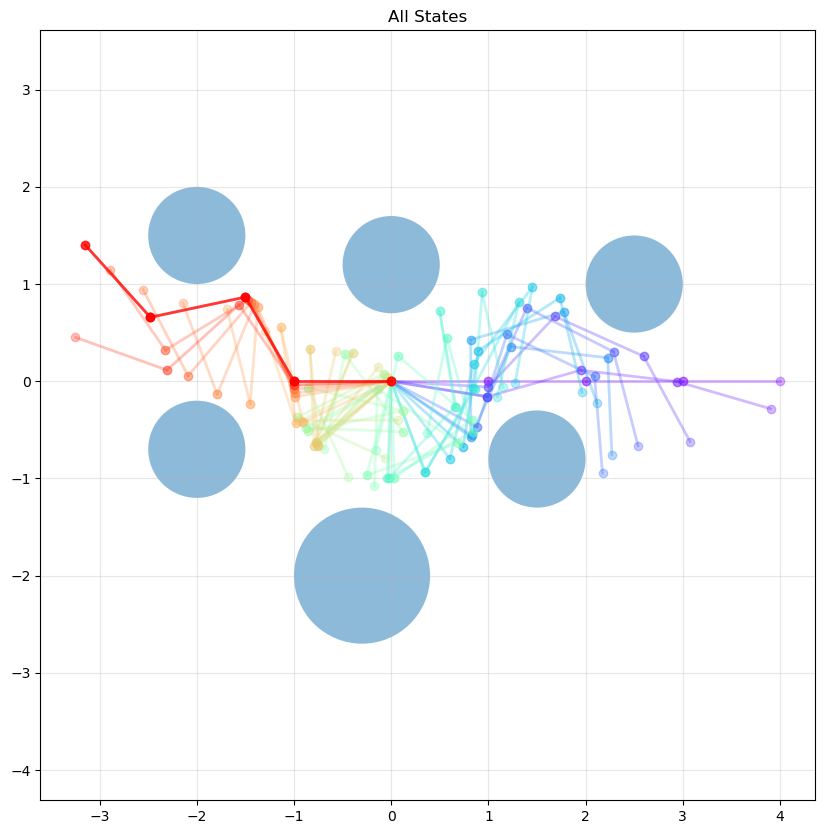

In [18]:
planner.set_weights_in_distant_func(1.0, 1.0, 1.0, 1.0)
planner.set_step_threshold(25)
if planner.launch():
    plann_list = planner.get_plan()
    state_list = []
    for i, angles in enumerate(plann_list):
        state = State(np.array(angles))
        state_list.append(state)
    visualize_states_single_plot(env, state_list)
    make_manipulator_gif(env, state_list, "solve_4R_15.gif")


With bigger step like 15 degree a shorter path and smaller overall iterations amout were got:

Iteration: 2149
Plan length: 37

Iteration: 924
Plan length: 31

for 25:
Iteration: 781
Plan length: 29

It connects to bigger research enviroment speed.